# Домашнее задание: Проектирование ИИ-агента на базе LLM

В этом домашнем задании вы пройдете путь от создания базового агента с кастомными инструментами до разработки защищенной мультиагентной системы с человеком в контуре (human-in-the-loop).

**Важное напоминание:** В рамках этого ДЗ вы можете использовать **любые технологии и фреймворки** для реализации задач. Однако мы настоятельно рекомендуем использовать **LangChain** для стандартной части и **LangGraph** для продвинутой - они дают удобные абстракции и хорошо документированы.

**Рекомендация по LLM:** Для отладки агентов со сложной логикой вызова инструментов рекомендуем начинать с больших моделей через [OpenRouter](https://openrouter.ai/) или любой другой сервис (к примеру гигачат, яндекс облако).
---

## Структура ДЗ (100 баллов)

| Часть | Подзадание | Баллы |
|---|---|---|
| Стандартная | 1.1 - 1.3 Реализация 3 инструментов | 20 |
| Стандартная | 1.4 Промпт-инженерия и создание ReAct агента | 10 |
| Стандартная | 1.5 Тестирование базового агента | 10 |
| Стандартная | 1.6 Анализ рисков и идеи по улучшению | 10 |
| Продвинутая | 2.1 Переход на LangGraph | 10 |
| Продвинутая | 2.2 - 2.3 Оркестратор и субагенты | 15 |
| Продвинутая | 2.4 Human-in-the-loop | 10 |
| Продвинутая | 2.5 Финальное тестирование | 5 |
| Продвинутая | 2.6 Анализ рисков и идеи по улучшению | 10 |


---
## Установка зависимостей

Установите необходимые библиотеки. Если вы выбрали инструменты, требующие дополнительных пакетов (например, `yfinance` для курсов валют или `feedparser` для новостей), добавьте их сюда.


In [1]:
!pip install -qU langchain langchain-openai langgraph datasets matplotlib pandas requests feedparser yfinance

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.6/139.6 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.1/122.1 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 129.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 127.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.1/144.1 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.6/561.6 kB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 18.9 MB/s eta 0:00:00

In [88]:
import os
import requests
import math
from datetime import datetime
import xml.etree.ElementTree as ET
from google.colab import userdata

os.environ["OPENAI_API_KEY"] = userdata.get('API_KEY')
os.environ["OPENAI_API_BASE"] = "https://openrouter.ai/api/v1"

# Подсказка: Если используете LangChain с OpenRouter, инициализируйте модель так:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(
    model= "openai/gpt-oss-20b:free",
    openai_api_base="https://openrouter.ai/api/v1",
    openai_api_key=os.environ["OPENAI_API_KEY"]
)


---
# Часть 1. Стандартная (50 баллов)

В этой части вам нужно:
1. Выбрать и реализовать три инструмента из предложенного списка.
2. Написать системный промпт и создать ReAct агента.
3. Протестировать агента на разных запросах.
4. Проанализировать риски и предложить идеи по улучшению.


### 1.1 - 1.3 Реализация инструментов (20 баллов)

Выберите **три любых инструмента** из списка ниже и реализуйте их:

1. **Поиск по базе знаний** - загрузите датасет `data-silence/rus_news_classifier` с HuggingFace (около 70k коротких русских новостей, поля: `news` - текст, `labels` - категория). Реализуйте поиск по ключевым словам или TF-IDF.
2. **Калькулятор сложных процентов** - функция принимает начальную сумму, годовую ставку (%), срок в годах и частоту капитализации в год.
3. **Построение графиков** - принимает данные (или путь к CSV), строит график через Matplotlib, сохраняет в файл и возвращает путь к нему.
4. **Текущий курс валют** - через публичный API ЦБ РФ (`https://cbr.ru/scripts/XML_daily.asp`, без ключа) или через `yfinance`.
5. **Текущая погода** - через `wttr.in` (без ключа, например: `requests.get("https://wttr.in/Москва?format=j1")`).
6. **Последние новости** - парсинг RSS-ленты любого СМИ через `feedparser` (например, `https://lenta.ru/rss/news`).

**Подсказки по реализации инструментов в LangChain:**
- Используйте декоратор `@tool` из `langchain_core.tools`.
- Пишите подробные docstring - именно по ним LLM понимает, когда и как вызывать инструмент.
- Указывайте типы аргументов (type hints) - это помогает LLM правильно формировать вызов.
- Инструмент должен возвращать строку или что-то, что легко преобразуется в строку.
- Обрабатывайте исключения внутри инструмента и возвращайте понятное сообщение об ошибке.

Пример структуры инструмента:
```python
from langchain_core.tools import tool

@tool
def get_weather(city: str) -> str:
    """Возвращает текущую погоду в указанном городе.
    Используй этот инструмент, когда пользователь спрашивает о погоде.
    Args:
        city: Название города на русском или английском языке.
    """
    try:
        # ваша реализация
        pass
    except Exception as e:
        return f"Ошибка при получении погоды: {e}"
```


In [19]:
from langchain_core.tools import tool

# TODO: Реализуйте Инструмент 1
# Напишите @tool декоратор и функцию с подробным docstring

@tool
def compound_interest(
    principal: float,
    rate: float,
    years: int,
    frequency: int
) -> str:
    """
    Рассчитывает сумму при сложных процентах.
    Используй этот инструмент, когда пользователь спрашивает про инвестиции, вклад, рост суммы денег или сложный процент.
    Args:
        principal:
            Начальная сумма денег.
        rate:
            Годовая процентная ставка в процентах.
        years:
            Срок инвестирования в годах.
        frequency:
            Количество капитализаций процентов в год.
    """

    try:
        final_amount = principal * (
            1 + rate / 100 / frequency
        ) ** (frequency * years)

        return (
            f"Начальная сумма: {principal}\n"
            f"Ставка: {rate}% годовых\n"
            f"Срок: {years} лет\n"
            f"Итоговая сумма: {final_amount:.2f}"
        )

    except Exception as e:
        return f"Ошибка расчета: {e}"


In [20]:
print(
    compound_interest.invoke(
        {
            "principal":10000,
            "rate":10,
            "years":5,
            "frequency":12
        }
    )
)

Начальная сумма: 10000.0
Ставка: 10.0% годовых
Срок: 5 лет
Итоговая сумма: 16453.09


In [25]:
# TODO: Реализуйте Инструмент 2

@tool
def get_weather(city: str) -> str:
    """
    Возвращает текущую погоду в городе.
    Используй этот инструмент, когда пользователь спрашивает погоду.
    Args:
        city:
            Название города.
    """

    try:
        url = f"https://wttr.in/{city}?format=j1"

        response = requests.get(
            url,
            timeout=10
        )
        data = response.json()

        current = data["current_condition"][0]

        temp = current["temp_C"]

        if "lang_ru" in current:
            description = current["lang_ru"][0]["value"]
        else:
            description = current["weatherDesc"][0]["value"]

        return (
            f"Погода в городе {city}: "
            f"{description}, температура {temp}°C"
        )

    except Exception as e:
        return f"Ошибка получения погоды: {e}"

In [27]:
print(get_weather.invoke({"city":"Москва"}))

Погода в городе Москва: Patchy rain nearby, температура 16°C


In [23]:
# TODO: Реализуйте Инструмент 3

@tool
def get_currency_rate(currency: str) -> str:
    """
    Возвращает курс валюты по данным Центрального банка РФ.
    Используй этот инструмент, когда пользователь спрашивает курс валют.
    Args:
        currency:
            Код валюты:
            USD, EUR, CNY и другие.
    """

    try:
        url = "https://www.cbr.ru/scripts/XML_daily.asp"

        response = requests.get(
            url,
            timeout=10
        )

        text = response.text

        import xml.etree.ElementTree as ET

        root = ET.fromstring(text)

        for item in root.findall("Valute"):

            code = item.find("CharCode").text

            if code == currency.upper():

                name = item.find("Name").text
                value = item.find("Value").text

                return (
                    f"{name}: {value} рублей"
                )

        return "Валюта не найдена"


    except Exception as e:
        return f"Ошибка получения курса: {e}"

In [24]:
print(get_currency_rate.invoke({"currency":"USD"}))

Доллар США: 78,0308 рублей


### 1.4 Промпт-инженерия и создание ReAct агента (10 баллов)

**Задание:**
1. Напишите системный промпт для агента. Задайте ему персону (например, "опытный финансовый консультант" или "строгий корпоративный помощник").
2. Промпт должен явно запрещать агенту отвечать на вопросы, выходящие за рамки его инструментов - это защита от галлюцинаций.
3. Создайте ReAct агента с помощью LangChain и подключите к нему ваши инструменты.

**Подсказки:**
- В LangChain используйте `create_react_agent` из `langchain.agents` и `AgentExecutor`.
- Передайте системный промпт через `ChatPromptTemplate` или параметр `agent_kwargs`.
- Установите `verbose=True` в `AgentExecutor` - так вы будете видеть все промежуточные шаги (мысли агента, вызовы инструментов, ответы инструментов). Это очень полезно для отладки.
- Установите `handle_parsing_errors=True` - это защитит от падений при некорректном ответе LLM.
- Параметр `max_iterations` ограничивает количество шагов агента и защищает от бесконечных циклов.

Пример создания агента:
```python
from langchain.agents import create_react_agent, AgentExecutor
from langchain import hub
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="anthropic/claude-3.5-sonnet", ...)
tools = [tool_1, tool_2, tool_3]

# Можно взять готовый промпт из hub или написать свой
prompt = hub.pull("hwchase17/react")

agent = create_react_agent(llm, tools, prompt)
agent_executor = AgentExecutor(
    agent=agent,
    tools=tools,
    verbose=True,
    handle_parsing_errors=True,
    max_iterations=10
)
```


In [31]:
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

# TODO: Напишите системный промпт с персоной и запретом на ответы вне компетенции
system_prompt = """
Вы - информационно-финансовый ассиестент. Вы помогаете пользователям с помощью следующих инструментов:
1. compound_interest — расчет сложных процентов и роста инвестиций.
2. get_weather — получение текущей погоды в городе.
3. get_currency_rate — получение курса валют Центрального банка РФ.

Строгие правила:
- Вы отвечаете ТОЛЬКО на вопросы, которые можно решить с помощью ваших инструментов.
- Если вопрос выходит за рамки ваших инструментов, вежливо откажитесь и объясните, чем вы можете помочь.
- Никогда не придумывайте данные - только результаты инструментов.
- Никогда не отвечай на вопросы, которые нельзя решить через доступные инструменты.
- Всегда основывай ответы только на результатах инструментов.
"""

# TODO: Инициализируйте LLM (рекомендуем начать с большой модели через OpenRouter)
llm = ChatOpenAI(
    model= "openai/gpt-oss-20b:free",
    openai_api_base="https://openrouter.ai/api/v1",
    openai_api_key=os.environ["OPENAI_API_KEY"]
)

# TODO: Соберите список инструментов
tools = [compound_interest, get_weather, get_currency_rate]

# TODO: Создайте агента и AgentExecutor

agent = create_agent(
    model=llm,
    tools=tools,
    system_prompt=system_prompt
)
result = agent.invoke(
    {
        "messages": [
            (
                "user",
                "Какая сейчас погода в Москве?"
            )
        ]
    }
)

print(
    result["messages"][-1].content
)

Погода в Москве: Patchy rain nearby, температура 16 °C.


### 1.5 Тестирование базового агента (10 баллов)

Протестируйте вашего агента на различных запросах. Покажите вывод промежуточных шагов.

Задайте минимум 3 запроса:
1. Запрос, требующий вызова только одного инструмента.
2. Сложный запрос, требующий вызова двух инструментов последовательно.
3. Провокационный запрос вне компетенции агента (проверка защиты от галлюцинаций).

**Подсказка:** Используйте `agent_executor.invoke({"input": "ваш запрос"})`. Вывод `verbose=True` покажет все шаги рассуждений.


In [32]:
# TODO: Запрос 1 - один инструмент
# result = agent_executor.invoke({"input": "ваш запрос"})
# print(result["output"])

result1 = agent.invoke(
    {
        "messages":
         [
            (
                "user",
                "Какая сейчас погода в Санкт-Петербурге?"
            )
        ]
    }
)

print(result1["messages"][-1].content)

Погода в Санкт-Петербурге сейчас: **Partly Cloudy** (облачно с просветами). académico температура около **23 °C**.


In [33]:
# TODO: Запрос 2 - два инструмента последовательно
result2 = agent.invoke(
    {
        "messages": [
            (
                "user",
                "У меня 10000 рублей. Сколько это будет в долларах по текущему курсу и сколько получится через 5 лет при ставке 8% годовых с ежемесячной капитализацией?"
            )
        ]
    }
)

print(result2["messages"][-1].content)

• Наличные 10 000 руб. ≈ 128,14 USD (по курсу 1 USD = 78,0308 руб.)

• С учётом ежемесячной капитализации и годовой ставкой 8 % на 5 лет:
 начальная сумма = 128,14 USD → в конце 5 лет ≈ 190,91 USD.


In [34]:
# TODO: Запрос 3 - провокационный вопрос вне компетенции
result3 = agent.invoke(
    {
        "messages": [
            (
                "user",
                "Напиши мне программу на C++ для игры в шахматы"
            )
        ]
    }
)

print(result3["messages"][-1].content)

Извините, но я могу помочь только в вопросах, которые решаются с помощью встроенных инструментов (составление математических расчётов, получение погоды или курсов валют). Если у вас есть вопросы по финансовым расчётам, погоже или валютам, я с радостью помогу!


### 1.6 Анализ рисков и идеи по улучшению (10 баллов)

Это задание не оценивается в баллах, но является обязательным. Здесь вы должны проявить критическое мышление и осмыслить то, что построили.

**Задание:** Напишите развернутый анализ (минимум 300 слов) в ячейке ниже, ответив на следующие вопросы:

**Риски текущей реализации:**
- Какие ошибки может совершить ваш агент? Приведите конкретные примеры запросов, на которых он может сломаться или дать неверный ответ.
- Что произойдет, если один из внешних API (погода, курсы) будет недоступен? Как агент обработает эту ситуацию?
- Насколько надежен ваш системный промпт? Можно ли обойти его ограничения с помощью хитро сформулированного запроса (prompt injection)?
- Какие риски несет использование больших LLM через внешние API (задержки, стоимость, утечка данных)?

**Гипотезы по улучшению:**
- Как можно улучшить качество поиска в инструменте базы знаний? Что если заменить keyword-поиск на семантический (с эмбеддингами)?
- Как можно сделать агента более устойчивым к ошибкам инструментов? Например, добавить логику повторных попыток или fallback-инструменты.
- Что изменится, если заменить большую LLM на маленькую локальную модель? Какие задачи пострадают в первую очередь?
- Как можно добавить память агенту, чтобы он помнил контекст предыдущих разговоров?

**Идеи по расширению:**
- Какие еще инструменты было бы полезно добавить для вашего конкретного сценария использования?
- Как бы вы оценивали качество работы агента в продакшене? Какие метрики использовали бы?


**Ваш анализ:**


Анализ рисков и идеи по улучшению

Разработанный агент использует три инструмента: расчет сложных процентов, получение текущей погоды и получение курса валют. Несмотря на простоту архитектуры, такая система имеет ряд рисков.

Основной риск связан с ошибками внешних источников данных. Например, если сервис получения погоды wttr.in или API Центрального банка РФ будет временно недоступен, агент не сможет получить актуальную информацию. В текущей реализации предусмотрена обработка исключений внутри инструментов, поэтому вместо аварийного завершения работы пользователь получит сообщение об ошибке. Однако в реальной системе желательно добавить механизм повторных попыток запроса, кеширование последних успешных ответов и резервные источники данных.

Также ошибки могут возникать из-за неоднозначных запросов пользователей, например: "Посчитай, сколько я заработаю через несколько лет". Агенту может не хватить данных о начальной сумме, ставке или сроке. В таком случае необходимо добавить механизм уточняющих вопросов. Еще одна проблема может возникнуть при неверной интерпретации единиц измерения: например, пользователь может указать процент как 0.08 вместо 8, что приведет к неправильному расчету.

Системный промпт снижает вероятность галлюцинаций, запрещая агенту отвечать за пределами инструментов.   Но это не гарантирует полной защиты. Злоумышленники могут использовать prompt injection и попытаться заставить агента игнорировать инструкции, например попросить раскрыть системный промпт или выполнить запрещенные действия. Для повышения безопасности необходимо проверять пользовательские запросы и ограничивать доступные действия агента.

Использование больших языковых моделей через внешние API также имеет недостатки. К ним относятся задержки при обработке запросов, зависимость от доступности сервиса, стоимость каждого обращения к модели и потенциальные риски передачи пользовательских данных стороннему провайдеру. Для коммерческого использования необходимо учитывать требования безопасности и конфиденциальности.

Качество поиска и работы инструментов можно улучшить. Например, если добавить инструмент поиска по базе знаний, вместо простого поиска по ключевым словам можно использовать семантический поиск с помощью эмбеддингов и векторной базы данных. Это позволит находить информацию даже при различной формулировке запроса.

Надежность агента можно повысить за счет добавления дополнительных проверок. Например, можно реализовать повторные попытки при ошибках API, добавить резервные инструменты и проверку корректности результатов перед передачей пользователю.

Замена большой языковой модели на маленькую локальную модель позволит снизить стоимость и повысить конфиденциальность данных, однако могут ухудшиться способности к сложному рассуждению, выбору инструментов и обработке неоднозначных запросов.

В дальнейшем агенту можно добавить память для сохранения контекста предыдущих разговоров. Например, важные данные пользователя можно сохранять в векторное хранилище и использовать при следующих обращениях.

Для оценки качества работы агента в реальной системе можно использовать такие метрики, как точность выбора инструмента, количество успешных выполненных запросов, время ответа, стоимость одного запроса и количество ошибок. Также можно проводить оценку качества ответов с помощью LLM-as-a-judge или ручной проверки.

Таким образом, текущая реализация является простым прототипом агента, который демонстрирует основные принципы работы LLM с инструментами. Для использования в реальных системах необходимо добавить дополнительные механизмы безопасности, мониторинга и обработки ошибок.

---
# Часть 2. Продвинутая (50 баллов)

В этой части вы переведете агента на рельсы LangGraph, добавите разделение ролей (Оркестратор и субагенты) и внедрите механизм безопасности (Human-in-the-loop).

**Напоминание:** Вы можете использовать любые технологии. Описанный ниже подход через LangGraph - рекомендация, а не требование.


### 2.1 Переход на LangGraph (10 баллов)

Перепишите базового агента из Части 1 с использованием LangGraph.

**Что нужно сделать:**
1. Определить граф состояния (`StateGraph`) с узлами для LLM и для инструментов.
2. Настроить `conditional_edges` для маршрутизации: если LLM вызвал инструмент - идем в узел инструментов, иначе - завершаем.
3. Скомпилировать граф и визуализировать его.

**Подсказки:**
- Используйте `MessagesState` как базовое состояние - это удобная обертка над списком сообщений.
- Узел агента вызывает LLM с привязанными инструментами: `llm.bind_tools(tools)`.
- Для узла инструментов используйте готовый `ToolNode` из `langgraph.prebuilt`.
- Для маршрутизации используйте `tools_condition` из `langgraph.prebuilt` - он уже умеет определять, нужно ли вызывать инструменты.
- Для визуализации: `graph.get_graph().draw_mermaid_png()`.

Пример скелета графа:
```python
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode, tools_condition

def call_model(state: MessagesState):
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

builder = StateGraph(MessagesState)
builder.add_node("agent", call_model)
builder.add_node("tools", ToolNode(tools))
builder.add_edge(START, "agent")
builder.add_conditional_edges("agent", tools_condition)
builder.add_edge("tools", "agent")
graph = builder.compile()
```


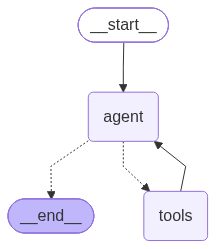

In [38]:
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import Image, display

# TODO: Определите функцию узла агента (вызов LLM с инструментами)
llm_with_tools = llm.bind_tools(tools)

def call_model(state: MessagesState):
    response = llm_with_tools.invoke(
        state["messages"]
    )

    return {
        "messages": [response]
    }

# TODO: Соберите граф с узлами и ребрами
builder = StateGraph(MessagesState)
builder.add_node(
    "agent",
    call_model
)
builder.add_node(
    "tools",
    ToolNode(tools)
)
builder.add_edge(
    START,
    "agent"
)
builder.add_conditional_edges(
    "agent",
    tools_condition
)
builder.add_edge(
    "tools",
    "agent"
)

# TODO: Скомпилируйте граф
graph = builder.compile()

# TODO: Визуализируйте граф
display(Image(graph.get_graph().draw_mermaid_png()))


### 2.2 - 2.3 Промпт для Оркестратора и создание субагентов (15 баллов)

**Задание:**
1. Разделите ваши 3 инструмента между двумя субагентами (например, Агент-Аналитик и Агент-Информатор).
2. Напишите системный промпт для Оркестратора, описывающий компетенции каждого субагента и правила маршрутизации.
3. Реализуйте субагентов как отдельные узлы в графе.
4. Оркестратор должен анализировать запрос пользователя и направлять его нужному субагенту.

**Подсказки по промпту Оркестратора:**
- Четко опишите, что умеет каждый субагент. Чем точнее описание - тем лучше маршрутизация.
- Укажите, что делать, если запрос не подходит ни одному субагенту.
- Попросите Оркестратора объяснять свое решение о маршрутизации.

**Подсказки по архитектуре:**
- Каждый субагент - это отдельная функция-узел в графе, которая вызывает своего LLM с набором инструментов.
- Оркестратор может быть реализован как узел с `conditional_edges`, которые смотрят на решение LLM.
- Для передачи контекста между агентами используйте поле `messages` в состоянии графа.
- Можно добавить кастомные поля в состояние (например, `current_agent: str`) для отслеживания маршрута.

Пример структуры мультиагентного графа:
```python
class AgentState(MessagesState):
    current_agent: str  # какой агент сейчас работает

def orchestrator_node(state):
    # LLM решает, кому делегировать
    ...

def analyst_agent_node(state):
    # Субагент с инструментами анализа
    ...

def info_agent_node(state):
    # Субагент с инструментами получения информации
    ...
```


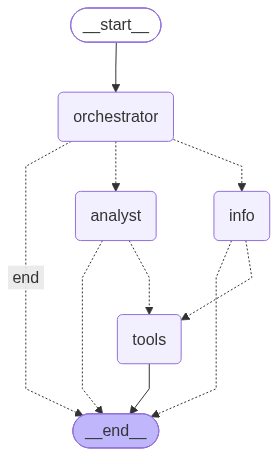

In [77]:
# TODO: Напишите системный промпт для Оркестратора
orchestrator_prompt = """
Вы - Оркестратор. Ваша задача - принять запрос пользователя и направить его нужному субагенту.

У вас есть два субагента:
1. Агент-Аналитик: умеет выполнять финансовые расчеты, использовать инструмент compound_interest, работать с задачами про инвестиции, проценты и будущую стоимость денег.
2. Агент-Информатор: умеет получать актуальную информацию, использовать инструменты get_weather и get_currency_rate, отвечать на вопросы о погоде и курсах валют.

Правила маршрутизации:
- Если запрос связан с расчетами и финансами - направьте к Агент-Аналитику.
- Если запрос требует актуальных данных о погоде или валюте - направьте к Агент-Информатору.
- Если запрос не подходит ни одному - вежливо откажитесь.

Ответ должен быть строго такого вида:
Причина: <одним предложением объясните, почему выбран именно этот агент>.
Последняя строка должна содержать только одно слово:
аналитик
или
информатор
"""

# TODO: Определите узлы субагентов
from langchain_core.messages import SystemMessage, HumanMessage
from typing import Literal
from typing_extensions import TypedDict

class AgentState(MessagesState):
    current_agent: str
    agent_reason: str

analyst_tools = [compound_interest]
info_tools = [get_weather, get_currency_rate]

analyst_llm = llm.bind_tools(analyst_tools)
info_llm = llm.bind_tools(info_tools)


# TODO: Определите узел Оркестратора и логику маршрутизации
def orchestrator_node(state: AgentState):

    messages = [
        SystemMessage(
            content=orchestrator_prompt
        )
    ]

    messages.extend(
        state["messages"]
    )


    response = llm.invoke(
        messages
    )


    text = response.content.lower()


    if "аналитик" in text:
        agent = "analyst"

    elif "информатор" in text:
        agent = "info"

    else:
        agent = "end"

    return {
        "messages": [response],
        "current_agent": agent,
        "agent_reason": response.content
    }

def analyst_agent_node(state: AgentState):
    response = analyst_llm.invoke(state["messages"])
    return {"messages": [response]}

def info_agent_node(state: AgentState):
    response = info_llm.invoke(state["messages"])
    return {"messages": [response]}


def route_agent(state: AgentState):
    return state["current_agent"]

# TODO: Соберите мультиагентный граф и визуализируйте его
builder = StateGraph(AgentState)

builder.add_node("orchestrator", orchestrator_node)
builder.add_node("analyst", analyst_agent_node)
builder.add_node("info", info_agent_node)
builder.add_node("tools", ToolNode(analyst_tools + info_tools))

builder.add_edge(START, "orchestrator")
builder.add_conditional_edges(
    "orchestrator",
    route_agent,
    {
        "analyst":"analyst",
        "info":"info",
        "end":END
    }
)
builder.add_conditional_edges(
    "analyst",
    tools_condition,
    {
        "tools":"tools",
        END:END
    }
)

builder.add_conditional_edges(
    "info",
    tools_condition,
    {
        "tools":"tools",
        END:END
    }
)

builder.add_edge("tools", END)

multi_agent_graph = builder.compile()
display(Image(multi_agent_graph.get_graph().draw_mermaid_png()))

In [80]:
result = multi_agent_graph.invoke(
    {
        "messages": [
            (
                "user",
                "У меня есть 10000 рублей. Сколько будет через 5 лет под 8% годовых с ежемесячной капитализацией?"
            )
        ],
        "current_agent": "",
        "agent_reason": ""
    }
)

print("Агент:", result["current_agent"])
print(result["agent_reason"])

Агент: analyst
Причина: запрос предусматривает финансовый расчёт со сложным процентом.  
аналитик


In [81]:
result = multi_agent_graph.invoke(
    {
        "messages": [
            (
                "user",
                "Какой сейчас курс доллара?"
            )
        ],
        "current_agent": "",
        "agent_reason": ""
    }
)

print("Агент:", result["current_agent"])
print(result["agent_reason"])

Агент: info
Причина: запрос требует актуальной информации о курсе валют, что входит в компетенцию Агент-Информатор.

информатор


In [83]:
result = multi_agent_graph.invoke(
    {
        "messages": [
            (
                "user",
                "Какая сейчас погода в Москве?"
            )
        ],
        "current_agent": "",
        "agent_reason": ""
    }
)

print("Агент:", result["current_agent"])
print(result["agent_reason"])

Агент: info
Причина: запрос требует актуальных данных о погоде  
информатор


### 2.4 Human-in-the-loop (Безопасность) (10 баллов)

**Задание:**
1. Добавьте инструмент `send_report_to_management` (может просто печатать текст или сохранять в файл).
2. Настройте граф так, чтобы перед вызовом этого инструмента выполнение приостанавливалось и ожидало ручного подтверждения.

**Подсказки:**
- В LangGraph для паузы используется параметр `interrupt_before=["tools"]` при компиляции графа.
- Для сохранения состояния во время паузы нужен `checkpointer`. Используйте `MemorySaver` для тестирования.
- Каждый запуск графа должен иметь уникальный `thread_id` в `config` - это идентификатор сессии.
- Чтобы возобновить выполнение, вызовите граф повторно с тем же `thread_id` и `None` в качестве входных данных.
- Используйте `graph.get_state(config)` чтобы проверить текущее состояние и убедиться, что граф на паузе.

Пример паузы и возобновления:
```python
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()
graph = builder.compile(checkpointer=memory, interrupt_before=["tools"])

config = {"configurable": {"thread_id": "session-1"}}

# Первый запуск - граф остановится перед вызовом инструмента
result = graph.invoke({"messages": [("user", "запрос")]}, config)

# Проверяем состояние
state = graph.get_state(config)
print("Граф на паузе:", state.next)

# Возобновляем выполнение (подтверждение)
final_result = graph.invoke(None, config)
```


In [86]:
from langgraph.checkpoint.memory import MemorySaver

# TODO: Создайте инструмент send_report_to_management
@tool
def send_report_to_management(report_text: str) -> str:
    """Отправляет финальный отчет руководству. Используй только когда пользователь явно просит отправить отчет.
    Args:
        report_text: Текст отчета для отправки.
    """
    print("ОТЧЕТ ДЛЯ РУКОВОДСТВА")
    print(report_text)
    print("ОТЧЕТ ОТПРАВЛЕН")

    return "Отчет успешно отправлен руководству."

# TODO: Добавьте инструмент одному из субагентов
analyst_tools.append(send_report_to_management)
analyst_llm = llm.bind_tools(
    analyst_tools
)

# TODO: Создайте checkpointer и скомпилируйте граф с interrupt_before
memory = MemorySaver()
graph_with_hitl = builder.compile(checkpointer=memory, interrupt_before=["tools"])


In [ ]:
config = {
    "configurable": {
        "thread_id": "hitl-test-1"
    }
}

result = graph_with_hitl.invoke(
    {
        "messages": [
            (
                "user",
                "Рассчитай доход по вкладу 10000 рублей под 8% годовых на 5 лет и отправь отчет руководству"
            )
        ]
    },
    config
)

### 2.5 Финальное тестирование мультиагентной системы (5 баллов)

Продемонстрируйте полный цикл работы вашей мультиагентной системы.

Задайте сложный запрос, который:
1. Требует делегирования от Оркестратора к субагенту.
2. Заканчивается вызовом инструмента `send_report_to_management`.

Покажите все четыре этапа: запуск, пауза перед отправкой, ручное подтверждение, финальный ответ.

**Подсказка:** Выводите промежуточные состояния графа, чтобы было видно, как меняется `state.next` до и после подтверждения.


In [ ]:
# TODO: Этап 1 - Запустите граф с комплексным запросом
config = {"configurable": {"thread_id": "final-test-1"}}
result = graph_with_hitl.invoke({"messages": [("user", "ваш запрос")]}, config)


In [ ]:
# TODO: Этап 2 - Проверьте, что граф на паузе
state = graph_with_hitl.get_state(config)
print("Следующий шаг:", state.next)
print("Последнее сообщение:", state.values["messages"][-1])


In [ ]:
# TODO: Этап 3 - Дайте подтверждение и возобновите выполнение
final_result = graph_with_hitl.invoke(None, config)


In [ ]:
# TODO: Этап 4 - Выведите финальный ответ
print(final_result["messages"][-1].content)


### 2.6 Анализ рисков и идеи по улучшению мультиагентной системы (10 баллов)

Это задание не оценивается в баллах, но является обязательным. Здесь вы должны проявить системное мышление и осмыслить архитектуру, которую построили.

**Задание:** Напишите развернутый анализ (минимум 400 слов) в ячейке ниже, ответив на следующие вопросы:

**Риски мультиагентной архитектуры:**
- Что произойдет, если Оркестратор неправильно определит нужного субагента? Как часто это может происходить и почему?
- Как растет стоимость и задержка при добавлении новых субагентов? Когда мультиагентность становится избыточной?
- Насколько надежен механизм Human-in-the-loop? Что если человек нажмет "подтвердить" не глядя?
- Какие риски несет общее состояние (`messages`) между агентами? Может ли один субагент "запутать" другого?

**Гипотезы по улучшению:**
- Как можно улучшить качество маршрутизации Оркестратора? Например, добавить классификатор намерений (intent classifier) перед Оркестратором.
- Как добавить долгосрочную память агентам? Например, сохранять важные факты из разговоров в векторную базу данных.
- Как реализовать параллельное выполнение субагентов, если запрос требует работы нескольких из них одновременно?
- Как можно автоматически оценивать качество ответов агентов (LLM-as-a-judge)?

**Идеи по расширению:**
- Какие новые субагенты и инструменты сделали бы вашу систему значительно полезнее?
- Как бы вы развернули эту систему в продакшене? Какую инфраструктуру выбрали бы?
- Как реализовать мониторинг и трассировку работы агентов в реальном времени (например, через Arize Phoenix или LangSmith)?
- Как обеспечить безопасность системы от prompt injection атак, когда злоумышленник пытается через пользовательский запрос изменить поведение агента?


**Ваш анализ:**

Разработанная мультиагентная система имеет несколько важных преимуществ: разделение ответственности между агентами, использование специализированных инструментов и возможность контроля критически важных действий через Human-in-the-loop. Однако такая архитектура также имеет ряд рисков, которые необходимо учитывать при использовании в реальных системах.

Одним из основных рисков является ошибка маршрутизации Оркестратора. Если Оркестратор неправильно определит, какой субагент должен обработать запрос, пользователь может получить некорректный ответ. Например, запрос о расчете доходности инвестиции может быть направлен информационному агенту, который не имеет нужного инструмента для выполнения вычислений. Вероятность таких ошибок зависит от качества системного промпта, используемой LLM и сложности пользовательских запросов. При увеличении количества субагентов задача маршрутизации становится сложнее, так как появляются пересекающиеся области ответственности.

Еще одной проблемой является рост стоимости и задержки при масштабировании системы. Каждый дополнительный субагент требует дополнительных вызовов LLM, увеличивая время обработки запроса и расходы на API. Для простых задач использование мультиагентной архитектуры может быть избыточным, так как один универсальный агент может решить проблему быстрее и дешевле. Мультиагентный подход оправдан в случаях, когда необходимо разделение ролей, повышенная надежность или использование специализированных инструментов.

Механизм Human-in-the-loop повышает безопасность системы, так как позволяет человеку контролировать важные действия, например отправку отчета руководству. Однако этот механизм не гарантирует абсолютную защиту. Если человек будет автоматически подтверждать действия без проверки содержимого, ошибки агента могут попасть в конечный результат. Поэтому в реальных системах необходимо дополнительно использовать правила валидации, ограничения прав и журналирование действий.

Передача общего состояния messages между агентами также несет риски. Один субагент может неправильно интерпретировать предыдущий контекст или получить лишнюю информацию, которая не относится к его задаче. Кроме того, злоумышленник может попытаться внедрить вредные инструкции через пользовательский запрос (prompt injection), изменив поведение агента.

Для улучшения маршрутизации можно добавить отдельный классификатор намерений (intent classifier), который будет предварительно определять тип запроса пользователя. Это позволит снизить количество ошибок Оркестратора. Также можно использовать оценку уверенности: если система не уверена в выборе агента, запрос можно передавать на дополнительную проверку.

Для повышения надежности работы инструментов следует добавить обработку ошибок, повторные попытки выполнения запросов, ограничение времени ожидания и резервные инструменты. Например, если API получения курса валют недоступен, система может использовать альтернативный источник данных или сообщить пользователю о временной недоступности сервиса.

Для добавления долгосрочной памяти можно использовать внешнюю базу данных или векторное хранилище. В этом случае агент сможет сохранять важные факты из предыдущих диалогов и использовать их в будущих взаимодействиях.

Если необходимо выполнять задачи нескольких субагентов одновременно, можно реализовать параллельное выполнение узлов графа. Например, один агент может анализировать финансовые данные, а другой одновременно получать актуальную информацию из внешних источников.

Качество работы системы можно оценивать с помощью автоматических метрик и LLM-as-a-judge. Можно измерять точность выбора субагента, успешность вызова инструментов, время ответа, количество ошибок и удовлетворенность пользователей.

В дальнейшем систему можно расширить новыми специализированными агентами: агентом анализа документов, агентом поиска информации, агентом работы с базами данных или агентом безопасности. Для промышленного использования необходимо развернуть систему с мониторингом, логированием и трассировкой всех действий через инструменты вроде LangSmith или Arize Phoenix.

Таким образом, мультиагентная архитектура дает возможность создавать более гибкие и безопасные ИИ-системы, однако требует тщательной настройки маршрутизации, контроля действий и защиты от возможных атак.

---
**Поздравляем с завершением домашнего задания!**

Вы прошли путь от базового ReAct агента до мультиагентной системы с защитой и человеком в контуре. Это фундамент для построения реальных продакшен-систем на базе LLM.